In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from pmdarima import auto_arima
import duckdb

# set global pandas display settings
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', None)

# ignore sklearn warnings
warnings.filterwarnings("ignore",category=FutureWarning, module="sklearn")
warnings.filterwarnings("ignore",category=DeprecationWarning)

/Users/wes/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# import split csv files for train, test, and validation

X_train = pd.read_csv(r'/Users/wes/Desktop/DS207/X_train.csv')
y_train = pd.read_csv(r'/Users/wes/Desktop/DS207/y_train.csv')

X_test = pd.read_csv(r'/Users/wes/Desktop/DS207/X_test.csv')
y_test = pd.read_csv(r'/Users/wes/Desktop/DS207/y_test.csv')

X_val = pd.read_csv(r'/Users/wes/Desktop/DS207/X_val.csv')
y_val = pd.read_csv(r'/Users/wes/Desktop/DS207/y_val.csv')

In [3]:
# convert all DATE columns to datetime, necessary for time-series forecasting with ARIMA
X_train['DATE'] = pd.to_datetime(X_train['DATE'])
X_test['DATE'] = pd.to_datetime(X_test['DATE'])
X_val['DATE'] = pd.to_datetime(X_val['DATE'])

# sort each dataframe by DATE to reindex in next step
X_train = X_train.sort_values('DATE')
y_train = y_train.loc[X_train.index]
X_test = X_test.sort_values('DATE')
y_test = y_test.loc[X_test.index]
X_val = X_val.sort_values('DATE')
y_val = y_val.loc[X_val.index]

# set DATE as index for all files
X_train = X_train.set_index('DATE')
y_train = y_train.set_index(X_train.index)
X_test = X_test.set_index('DATE')
y_test = y_test.set_index(X_test.index)
X_val = X_val.set_index('DATE')
y_val = y_val.set_index(X_val.index)

In [4]:
# convert all boolean columns to integers
for col in X_train.columns:
    if X_train[col].dtype == bool:
        X_train[col] = X_train[col].astype(int)
        X_val[col] = X_val[col].astype(int)
        X_test[col] = X_test[col].astype(int)

In [5]:
# confirm that all columsn converted to int where applicable

X_train.head()

,T2M_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401,PRECTOTCORR_0401,WS10M_0401,WS10M_MAX_0401,WS10M_MIN_0401,WS10M_RANGE_0401,WD10M_0401,T2M_0402,T2M_MAX_0402,T2M_MIN_0402,QV2M_0402,RH2M_0402,PRECTOTCORR_0402,WS10M_0402,WS10M_MAX_0402,WS10M_MIN_0402,WS10M_RANGE_0402,WD10M_0402,T2M_0403,T2M_MAX_0403,T2M_MIN_0403,QV2M_0403,RH2M_0403,PRECTOTCORR_0403,WS10M_0403,WS10M_MAX_0403,WS10M_MIN_0403,WS10M_RANGE_0403,WD10M_0403,T2M_0404,T2M_MAX_0404,T2M_MIN_0404,QV2M_0404,RH2M_0404,PRECTOTCORR_0404,WS10M_0404,WS10M_MAX_0404,WS10M_MIN_0404,WS10M_RANGE_0404,WD10M_0404,T2M_0405,T2M_MAX_0405,T2M_MIN_0405,QV2M_0405,RH2M_0405,PRECTOTCORR_0405,WS10M_0405,WS10M_MAX_0405,WS10M_MIN_0405,WS10M_RANGE_0405,WD10M_0405,T2M_0406,T2M_MAX_0406,T2M_MIN_0406,QV2M_0406,RH2M_0406,PRECTOTCORR_0406,WS10M_0406,WS10M_MAX_0406,WS10M_MIN_0406,WS10M_RANGE_0406,WD10M_0406,T2M_0407,T2M_MAX_0407,T2M_MIN_0407,QV2M_0407,RH2M_0407,PRECTOTCORR_0407,WS10M_0407,WS10M_MAX_0407,WS10M_MIN_0407,WS10M_RANGE_0407,WD10M_0407,T2M_0401_LAG_3,T2M_MAX_0401_LAG_3,T2M_MIN_0401_LAG_3,QV2M_0401_LAG_3,RH2M_0401_LAG_3,PRECTOTCORR_0401_LAG_3,WS10M_0401_LAG_3,WS10M_MAX_0401_LAG_3,WS10M_MIN_0401_LAG_3,WS10M_RANGE_0401_LAG_3,WD10M_0401_LAG_3,T2M_0402_LAG_3,T2M_MAX_0402_LAG_3,T2M_MIN_0402_LAG_3,QV2M_0402_LAG_3,RH2M_0402_LAG_3,PRECTOTCORR_0402_LAG_3,WS10M_0402_LAG_3,WS10M_MAX_0402_LAG_3,WS10M_MIN_0402_LAG_3,WS10M_RANGE_0402_LAG_3,WD10M_0402_LAG_3,T2M_0403_LAG_3,T2M_MAX_0403_LAG_3,T2M_MIN_0403_LAG_3,QV2M_0403_LAG_3,RH2M_0403_LAG_3,PRECTOTCORR_0403_LAG_3,WS10M_0403_LAG_3,WS10M_MAX_0403_LAG_3,WS10M_MIN_0403_LAG_3,WS10M_RANGE_0403_LAG_3,WD10M_0403_LAG_3,T2M_0404_LAG_3,T2M_MAX_0404_LAG_3,T2M_MIN_0404_LAG_3,QV2M_0404_LAG_3,RH2M_0404_LAG_3,PRECTOTCORR_0404_LAG_3,WS10M_0404_LAG_3,WS10M_MAX_0404_LAG_3,WS10M_MIN_0404_LAG_3,WS10M_RANGE_0404_LAG_3,WD10M_0404_LAG_3,T2M_0405_LAG_3,T2M_MAX_0405_LAG_3,T2M_MIN_0405_LAG_3,QV2M_0405_LAG_3,RH2M_0405_LAG_3,PRECTOTCORR_0405_LAG_3,WS10M_0405_LAG_3,WS10M_MAX_0405_LAG_3,WS10M_MIN_0405_LAG_3,WS10M_RANGE_0405_LAG_3,WD10M_0405_LAG_3,T2M_0406_LAG_3,T2M_MAX_0406_LAG_3,T2M_MIN_0406_LAG_3,QV2M_0406_LAG_3,RH2M_0406_LAG_3,PRECTOTCORR_0406_LAG_3,WS10M_0406_LAG_3,WS10M_MAX_0406_LAG_3,WS10M_MIN_0406_LAG_3,WS10M_RANGE_0406_LAG_3,WD10M_0406_LAG_3,T2M_0407_LAG_3,T2M_MAX_0407_LAG_3,T2M_MIN_0407_LAG_3,QV2M_0407_LAG_3,RH2M_0407_LAG_3,PRECTOTCORR_0407_LAG_3,WS10M_0407_LAG_3,WS10M_MAX_0407_LAG_3,WS10M_MIN_0407_LAG_3,WS10M_RANGE_0407_LAG_3,WD10M_0407_LAG_3,T2M_0401_LAG_7,T2M_MAX_0401_LAG_7,T2M_MIN_0401_LAG_7,QV2M_0401_LAG_7,RH2M_0401_LAG_7,PRECTOTCORR_0401_LAG_7,WS10M_0401_LAG_7,WS10M_MAX_0401_LAG_7,WS10M_MIN_0401_LAG_7,WS10M_RANGE_0401_LAG_7,WD10M_0401_LAG_7,T2M_0402_LAG_7,T2M_MAX_0402_LAG_7,T2M_MIN_0402_LAG_7,QV2M_0402_LAG_7,RH2M_0402_LAG_7,PRECTOTCORR_0402_LAG_7,WS10M_0402_LAG_7,WS10M_MAX_0402_LAG_7,WS10M_MIN_0402_LAG_7,WS10M_RANGE_0402_LAG_7,WD10M_0402_LAG_7,T2M_0403_LAG_7,T2M_MAX_0403_LAG_7,T2M_MIN_0403_LAG_7,QV2M_0403_LAG_7,RH2M_0403_LAG_7,PRECTOTCORR_0403_LAG_7,WS10M_0403_LAG_7,WS10M_MAX_0403_LAG_7,WS10M_MIN_0403_LAG_7,WS10M_RANGE_0403_LAG_7,WD10M_0403_LAG_7,T2M_0404_LAG_7,T2M_MAX_0404_LAG_7,T2M_MIN_0404_LAG_7,QV2M_0404_LAG_7,RH2M_0404_LAG_7,PRECTOTCORR_0404_LAG_7,WS10M_0404_LAG_7,WS10M_MAX_0404_LAG_7,WS10M_MIN_0404_LAG_7,WS10M_RANGE_0404_LAG_7,WD10M_0404_LAG_7,T2M_0405_LAG_7,T2M_MAX_0405_LAG_7,T2M_MIN_0405_LAG_7,QV2M_0405_LAG_7,RH2M_0405_LAG_7,PRECTOTCORR_0405_LAG_7,WS10M_0405_LAG_7,WS10M_MAX_0405_LAG_7,WS10M_MIN_0405_LAG_7,WS10M_RANGE_0405_LAG_7,WD10M_0405_LAG_7,T2M_0406_LAG_7,T2M_MAX_0406_LAG_7,T2M_MIN_0406_LAG_7,QV2M_0406_LAG_7,RH2M_0406_LAG_7,PRECTOTCORR_0406_LAG_7,WS10M_0406_LAG_7,WS10M_MAX_0406_LAG_7,WS10M_MIN_0406_LAG_7,WS10M_RANGE_0406_LAG_7,WD10M_0406_LAG_7,T2M_0407_LAG_7,T2M_MAX_0407_LAG_7,T2M_MIN_0407_LAG_7,QV2M_0407_LAG_7,RH2M_0407_LAG_7,PRECTOTCORR_0407_LAG_7,WS10M_0407_LAG_7,WS10M_MAX_0407_LAG_7,WS10M_MIN_0407_LAG_7,WS10M_RANGE_0407_LAG_7,WD10M_0407_LAG_7,T2M_0401_LAG_14,T2M_MAX_0401_LAG_14,T2M_MIN_0401_LAG_14,QV2M_0401_LAG_14,RH2M_0401_LAG_14,PRECTOTCORR_0401_LAG_14,

In [6]:
# create dictionaries to loop through each ARIMA model by region

def get_dicts(x):
    '''Returns the dictionaries needed for each SARIMAX run by region.'''
    regions = list(range(401,408))
    
    y_train_d = {}
    y_val_d = {}
    y_test_d = {}
    cols_d = {}
    
    for i in regions:
        region_str = f'conus_code_{i}.0'
        y_train_d[i] = y_train[x] * X_train[region_str]
        y_val_d[i] = y_val[x] * X_val[region_str]
        y_test_d[i] = y_test[x] * X_test[region_str]
        cols_d[i] = [col for col in X_train.columns if f'{i}' in col and 'conus_code' not in col and 'LAG' not in col]
        
    return y_train_d, y_val_d, y_test_d, cols_d

In [7]:
# run function above for 3 day time period
y_train_d, y_val_d, y_test_d, cols_d = get_dicts('y_3')

In [8]:
# use auto_arima to identify key ARIMA  and seasonal hyperparameters
model_auto = auto_arima(y_train_d[401]
                       , exogenous = cols_d[401]
                       , start_p = 1
                       , start_q = 0
                       , max_p = 2
                       , max_q = 2
                       , seasonal = True
                       , m = 7
                       , max_P = 1
                       , max_Q = 1
                       , stepwise = True
                       , max_d = 1
                       , max_D = 1
                       , trace = False)

# get the best performing hyperparameters
print('ARIMA order: ', model_auto.order)
print('seasonal order: ', model_auto.seasonal_order)

# get predictions and RMSE
pred_auto = model_auto.predict(n_periods = len(y_val_d[401])
                              , X=X_val[cols_d[401]])
rmse_auto = np.sqrt(mean_squared_error(y_val_d[401], pred_auto))
print('---')
print('RMSE: ', rmse_auto)

ARIMA order:  (1, 1, 2)
seasonal order:  (0, 0, 0, 7)
---
RMSE:  1.407009996143774


/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [9]:
# create a dictionary to restore the results of each SARIMAX model run by region

models = {}
model_fits = {}

# loop through each of the regions to run SARIMAX, using hyperparameters from auto arima
for i in list(range(401,408)):
    models[i] = SARIMAX(y_train_d[i]
                        , exog = X_train[cols_d[i]]
                        , order = (1, 0, 1) # derived from auto_arima
                        , seasonal_order = (1, 0, 0, 7) # derived from auto_arima
                        , enforce_stationarity = False)
    model_fits[i] = models[i].fit(disp = False
                                 , quit = True) # supress warnings

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/base/optimizer.py:18: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: quit. After release 0.14, this will raise.
  warnings.warn(
/Users/wes/anaconda3/lib/python3.11/site-packages

In [30]:
# generate empy dicts for validation set predictions and actuals, convert to binary
val_preds = {}
val_preds_binary = {}
y_val_binary = {}

# loop through to get validation set predictions for each region
for i in list(range(401,408)):
    val_preds[i] = model_fits[i].forecast(steps = len(y_val_d[i]), exog = X_val[cols_d[i]])
    
# set arbitrary threshold for binary conversion
threshold = 0.5
for i in list(range(401,408)):
    val_preds_binary[i] = (val_preds[i] > threshold).astype(int)
    y_val_binary[i] = (y_val_d[i] > 0).astype(int)

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exce

In [35]:
# get unique dates list from X_val to create unified dataframe
unique_dates = X_val.index.unique()
daily_results = []

for date in unique_dates:
    date_mask = X_val.index == date
    
    # initially, set all values to False
    fire_pred = False
    fire_actual = False
    
    # loop through each of the region results and get actual and predicted values
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        region_actuals = y_val_binary[i][date_mask]
        # verifies if fire was predicted on this day
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_pred = True
        # verifies if a fire actually occured on this day
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actual = True
            
    # append daily predicted and actual binary values to daily_results
    daily_results.append({
        'date': date
        , 'fire_predicted': 1 if fire_pred else 0
        , 'fire_actual': 1 if fire_actual else 0})
        
# create a dataframe for the daily results, use to calculate metrics below
daily_df = pd.DataFrame(daily_results)

# calculate and store all metrics for y_3
y3_accuracy = accuracy_score(daily_df['fire_actual'], daily_df['fire_predicted'])
y3_precision = precision_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y3_recall = recall_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y3_f1 = f1_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y3_cm = confusion_matrix(daily_df['fire_actual'], daily_df['fire_predicted'])

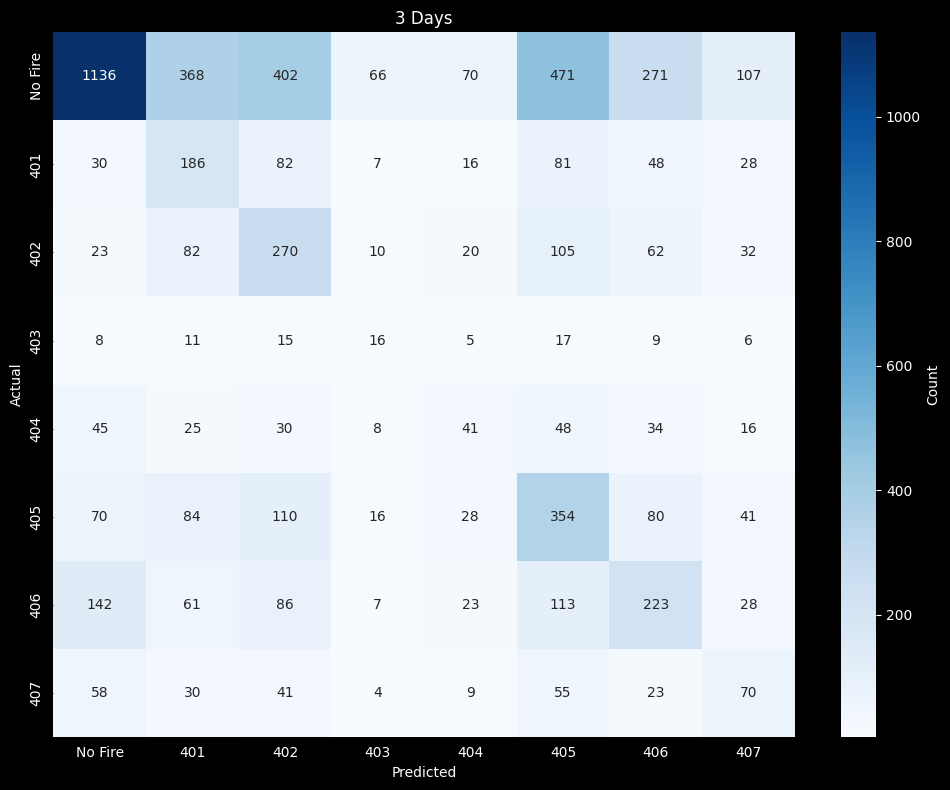

In [41]:
# create an initial blank matrix to break out by region
regions = list(range(401,408))
region_cm = np.zeros((8, 8)
                     , dtype=int)
labels = ['No Fire'] + regions

# create empty list to initialize confusion matrix by region
classifications = []

# loop through all actual and predicted values and store together as a dict
for date in unique_dates:
    date_mask = X_val.index == date
    fire_actuals = []
    fire_preds = []
    # get predicted and actual values for each region IF they are present
    for i in list(range(401,408)):
        region_actuals = y_val_binary[i][date_mask]
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actuals.append(i)
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_preds.append(i)
    # get values for days without fires
    if not fire_actuals:
        actual_class = 'No Fire'
        if not fire_preds:
            region_cm[0, 0] += 1 # append true negatives
        else:
            for region in fire_preds:
                pred_idx = regions.index(region) + 1
                region_cm[0, pred_idx] += 1 # append false positives
    else:
        for actual_region in fire_actuals:
            actual_idx = regions.index(actual_region) + 1
            if not fire_preds:
                region_cm[actual_idx, 0] += 1 # append false negatives
            else:
                for pred_region in fire_preds:
                    pred_idx = regions.index(pred_region) + 1
                    region_cm[actual_idx, pred_idx] += 1   
    # append the details to the original list
    classifications.append({
        'date': date
        , 'actual_regions': fire_actuals
        if fire_actuals else ['No Fire']
        , 'predicted_regions': fire_preds if fire_preds else ['No Fire']})
                
            
# generate dataframe for both the classifications and confusion matrix
classification_df = pd.DataFrame(classifications)
cm_df = pd.DataFrame(region_cm
                    , index=labels
                    , columns=labels) 

# generate a plot of the matrix
plt.figure(figsize=(10, 8)
          , facecolor = 'black')
ax = plt.axes()
sns.heatmap(cm_df
            , annot=True
            , fmt='d'
            , cmap='Blues')
# format the colorbar to use white text
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.tick_params(colors='white')
cbar.set_label('Count', color='white')

# add formatting, set globals, save figure
plt.xlabel('Predicted', color = 'white')
plt.ylabel('Actual', color = 'white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.title('3 Days', color = 'white')
plt.savefig('y_3.png'
            , dpi=300
            , bbox_inches='tight'
            , facecolor='black')
plt.tight_layout()
plt.show()

In [55]:
# run function above for 7 day time period
y_train_d, y_val_d, y_test_d, cols_d = get_dicts('y_7')

In [56]:
# create a dictionary to restore the results of each SARIMAX model run by region

models = {}
model_fits = {}

# loop through each of the regions to run SARIMAX, using hyperparameters from auto arima
for i in list(range(401,408)):
    models[i] = SARIMAX(y_train_d[i]
                        , exog = X_train[cols_d[i]]
                        , order = (1, 0, 1) # derived from auto_arima
                        , seasonal_order = (1, 0, 0, 7) # derived from auto_arima
                        , enforce_stationarity = False)
    model_fits[i] = models[i].fit(disp = False
                                 , quit = True) # supress warnings

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/base/optimizer.py:18: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: quit. After release 0.14, this will raise.
  warnings.warn(
/Users/wes/anaconda3/lib/python3.11/site-packages

In [57]:
# generate empy dicts for validation set predictions and actuals, convert to binary
val_preds = {}
val_preds_binary = {}
y_val_binary = {}

# loop through to get validation set predictions for each region
for i in list(range(401,408)):
    val_preds[i] = model_fits[i].forecast(steps = len(y_val_d[i]), exog = X_val[cols_d[i]])
    
# set arbitrary threshold for binary conversion
threshold = 0.5
for i in list(range(401,408)):
    val_preds_binary[i] = (val_preds[i] > threshold).astype(int)
    y_val_binary[i] = (y_val_d[i] > 0).astype(int)

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exce

In [58]:
# get unique dates list from X_val to create unified dataframe
unique_dates = X_val.index.unique()
daily_results = []

for date in unique_dates:
    date_mask = X_val.index == date
    
    # initially, set all values to False
    fire_pred = False
    fire_actual = False
    
    # loop through each of the region results and get actual and predicted values
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        region_actuals = y_val_binary[i][date_mask]
        # verifies if fire was predicted on this day
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_pred = True
        # verifies if a fire actually occured on this day
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actual = True
            
    # append daily predicted and actual binary values to daily_results
    daily_results.append({
        'date': date
        , 'fire_predicted': 1 if fire_pred else 0
        , 'fire_actual': 1 if fire_actual else 0})
        
# create a dataframe for the daily results, use to calculate metrics below
daily_df = pd.DataFrame(daily_results)

# calculate and store all metrics for y_7
y7_accuracy = accuracy_score(daily_df['fire_actual'], daily_df['fire_predicted'])
y7_precision = precision_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y7_recall = recall_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y7_f1 = f1_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y7_cm = confusion_matrix(daily_df['fire_actual'], daily_df['fire_predicted'])

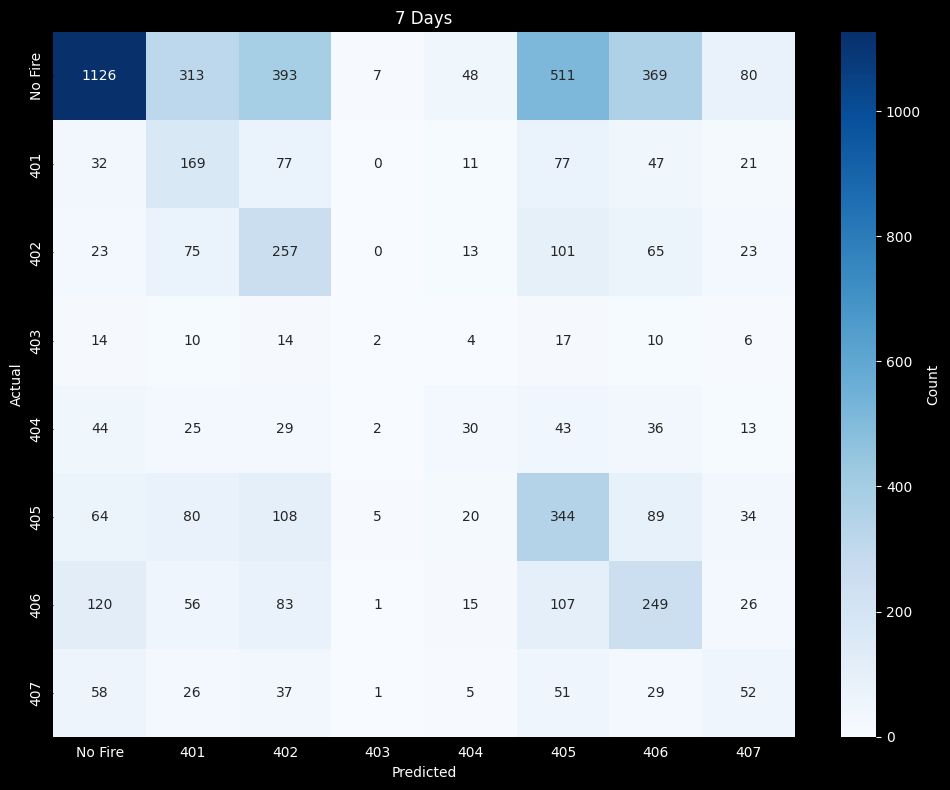

In [46]:
# create an initial blank matrix to break out by region
regions = list(range(401,408))
region_cm = np.zeros((8, 8)
                     , dtype=int)
labels = ['No Fire'] + regions

# create empty list to initialize confusion matrix by region
classifications = []

# loop through all actual and predicted values and store together as a dict
for date in unique_dates:
    date_mask = X_val.index == date
    fire_actuals = []
    fire_preds = []
    # get predicted and actual values for each region IF they are present
    for i in list(range(401,408)):
        region_actuals = y_val_binary[i][date_mask]
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actuals.append(i)
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_preds.append(i)
    # get values for days without fires
    if not fire_actuals:
        actual_class = 'No Fire'
        if not fire_preds:
            region_cm[0, 0] += 1 # append true negatives
        else:
            for region in fire_preds:
                pred_idx = regions.index(region) + 1
                region_cm[0, pred_idx] += 1 # append false positives
    else:
        for actual_region in fire_actuals:
            actual_idx = regions.index(actual_region) + 1
            if not fire_preds:
                region_cm[actual_idx, 0] += 1 # append false negatives
            else:
                for pred_region in fire_preds:
                    pred_idx = regions.index(pred_region) + 1
                    region_cm[actual_idx, pred_idx] += 1   
    # append the details to the original list
    classifications.append({
        'date': date
        , 'actual_regions': fire_actuals
        if fire_actuals else ['No Fire']
        , 'predicted_regions': fire_preds if fire_preds else ['No Fire']})
                
            
# generate dataframe for both the classifications and confusion matrix
classification_df = pd.DataFrame(classifications)
cm_df = pd.DataFrame(region_cm
                    , index=labels
                    , columns=labels) 

# generate a plot of the matrix
plt.figure(figsize=(10, 8)
          , facecolor = 'black')
ax = plt.axes()
sns.heatmap(cm_df
            , annot=True
            , fmt='d'
            , cmap='Blues')
# format the colorbar to use white text
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.tick_params(colors='white')
cbar.set_label('Count', color='white')

# add formatting, set globals, save figure
plt.xlabel('Predicted', color = 'white')
plt.ylabel('Actual', color = 'white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.title('7 Days', color = 'white')
plt.savefig('y_7.png'
            , dpi=300
            , bbox_inches='tight'
            , facecolor='black')
plt.tight_layout()
plt.show()

In [47]:
# run function above for 14 day time period
y_train_d, y_val_d, y_test_d, cols_d = get_dicts('y_14')

In [48]:
# create a dictionary to restore the results of each SARIMAX model run by region

models = {}
model_fits = {}

# loop through each of the regions to run SARIMAX, using hyperparameters from auto arima
for i in list(range(401,408)):
    models[i] = SARIMAX(y_train_d[i]
                        , exog = X_train[cols_d[i]]
                        , order = (1, 0, 1) # derived from auto_arima
                        , seasonal_order = (1, 0, 0, 7) # derived from auto_arima
                        , enforce_stationarity = False)
    model_fits[i] = models[i].fit(disp = False
                                 , quit = True) # supress warnings

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/base/optimizer.py:18: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: quit. After release 0.14, this will raise.
  warnings.warn(
/Users/wes/anaconda3/lib/python3.11/site-packages

In [49]:
# generate empy dicts for validation set predictions and actuals, convert to binary
val_preds = {}
val_preds_binary = {}
y_val_binary = {}

# loop through to get validation set predictions for each region
for i in list(range(401,408)):
    val_preds[i] = model_fits[i].forecast(steps = len(y_val_d[i]), exog = X_val[cols_d[i]])
    
# set arbitrary threshold for binary conversion
threshold = 0.5
for i in list(range(401,408)):
    val_preds_binary[i] = (val_preds[i] > threshold).astype(int)
    y_val_binary[i] = (y_val_d[i] > 0).astype(int)

/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/wes/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exce

In [52]:
# get unique dates list from X_val to create unified dataframe
unique_dates = X_val.index.unique()
daily_results = []

for date in unique_dates:
    date_mask = X_val.index == date
    
    # initially, set all values to False
    fire_pred = False
    fire_actual = False
    
    # loop through each of the region results and get actual and predicted values
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        region_actuals = y_val_binary[i][date_mask]
        # verifies if fire was predicted on this day
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_pred = True
        # verifies if a fire actually occured on this day
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actual = True
            
    # append daily predicted and actual binary values to daily_results
    daily_results.append({
        'date': date
        , 'fire_predicted': 1 if fire_pred else 0
        , 'fire_actual': 1 if fire_actual else 0})
        
# create a dataframe for the daily results, use to calculate metrics below
daily_df = pd.DataFrame(daily_results)

# calculate and store all metrics for y_7
y14_accuracy = accuracy_score(daily_df['fire_actual'], daily_df['fire_predicted'])
y14_precision = precision_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y14_recall = recall_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y14_f1 = f1_score(daily_df['fire_actual'], daily_df['fire_predicted'], zero_division=0)
y14_cm = confusion_matrix(daily_df['fire_actual'], daily_df['fire_predicted'])

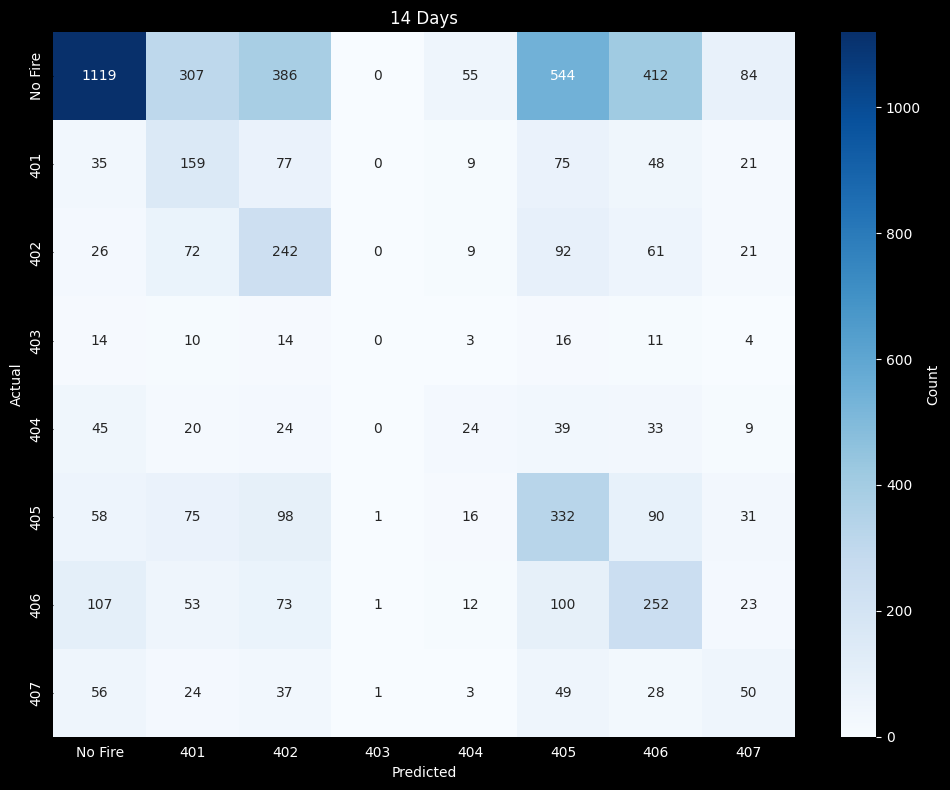

In [53]:
# create an initial blank matrix to break out by region
regions = list(range(401,408))
region_cm = np.zeros((8, 8)
                     , dtype=int)
labels = ['No Fire'] + regions

# create empty list to initialize confusion matrix by region
classifications = []

# loop through all actual and predicted values and store together as a dict
for date in unique_dates:
    date_mask = X_val.index == date
    fire_actuals = []
    fire_preds = []
    # get predicted and actual values for each region IF they are present
    for i in list(range(401,408)):
        region_actuals = y_val_binary[i][date_mask]
        if len(region_actuals) > 0 and np.any(region_actuals == 1):
            fire_actuals.append(i)
    for i in list(range(401,408)):
        region_preds = val_preds_binary[i][date_mask]
        if len(region_preds) > 0 and np.any(region_preds == 1):
            fire_preds.append(i)
    # get values for days without fires
    if not fire_actuals:
        actual_class = 'No Fire'
        if not fire_preds:
            region_cm[0, 0] += 1 # append true negatives
        else:
            for region in fire_preds:
                pred_idx = regions.index(region) + 1
                region_cm[0, pred_idx] += 1 # append false positives
    else:
        for actual_region in fire_actuals:
            actual_idx = regions.index(actual_region) + 1
            if not fire_preds:
                region_cm[actual_idx, 0] += 1 # append false negatives
            else:
                for pred_region in fire_preds:
                    pred_idx = regions.index(pred_region) + 1
                    region_cm[actual_idx, pred_idx] += 1   
    # append the details to the original list
    classifications.append({
        'date': date
        , 'actual_regions': fire_actuals
        if fire_actuals else ['No Fire']
        , 'predicted_regions': fire_preds if fire_preds else ['No Fire']})
                
            
# generate dataframe for both the classifications and confusion matrix
classification_df = pd.DataFrame(classifications)
cm_df = pd.DataFrame(region_cm
                    , index=labels
                    , columns=labels) 

# generate a plot of the matrix
plt.figure(figsize=(10, 8)
          , facecolor = 'black')
ax = plt.axes()
sns.heatmap(cm_df
            , annot=True
            , fmt='d'
            , cmap='Blues')
# format the colorbar to use white text
cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
cbar.ax.tick_params(colors='white')
cbar.set_label('Count', color='white')

# add formatting, set globals, save figure
plt.xlabel('Predicted', color = 'white')
plt.ylabel('Actual', color = 'white')
plt.xticks(color='white')
plt.yticks(color='white')
plt.title('14 Days', color = 'white')
plt.savefig('y_14.png'
            , dpi=300
            , bbox_inches='tight'
            , facecolor='black')
plt.tight_layout()
plt.show()

In [59]:
# print out all aggregate scores for y3, y7, y14

print('3 Day Accuracy:', round(y3_accuracy,4))
print('3 Day Precision:', round(y3_precision,4))
print('3 Day Recall:', round(y3_recall,4))
print('3 Day F1:', round(y3_f1,4))
print('---')
print('7 Day Accuracy:', round(y7_accuracy,4))
print('7 Day Precision:', round(y7_precision,4))
print('7 Day Recall:', round(y7_recall,4))
print('7 Day F1:', round(y7_f1,4))
print('---')
print('14 Day Accuracy:', round(y14_accuracy,4))
print('14 Day Precision:', round(y14_precision,4))
print('14 Day Recall:', round(y14_recall,4))
print('14 Day F1:', round(y14_f1,4))

3 Day Accuracy: 0.6719
3 Day Precision: 0.5582
3 Day Recall: 0.6904
3 Day F1: 0.6173
---
7 Day Accuracy: 0.659
7 Day Precision: 0.529
7 Day Recall: 0.6919
7 Day F1: 0.5996
---
14 Day Accuracy: 0.6501
14 Day Precision: 0.5081
14 Day Recall: 0.6954
14 Day F1: 0.5871
